# 01 — Grounding DINO 单图推理 Demo

本 Notebook 用于验证环境是否正确配置，并对单张图像运行 Grounding DINO 推理。

**运行前提**：
1. `conda activate cv`
2. `pip install -e third_party/GroundingDINO`（或在 configs 中设置 `backend: hf`）
3. 已下载权重：`python scripts/download_weights.py`

In [ ]:
import sys
from pathlib import Path

# 将项目根加入 PATH
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('项目根目录:', ROOT)

项目根目录: C:\code\cv\project\cv-project


In [2]:
# 验证环境
%run ../scripts/setup_env.py

Python: 3.10.13 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:24:38) [MSC v.1916 64 bit (AMD64)]
Executable: c:\Users\Hao\miniconda3\python.exe

── 核心依赖 ──────────────────────────────────
  [OK] torch 2.1.2+cu118  
  CUDA available: True  (NVIDIA GeForce RTX 4060 Laptop GPU)
  显存: 8.0 GB


c:\Users\Hao\miniconda3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [OK] torchvision 0.16.2+cu118  
  [OK] transformers 4.47.1  
  [OK] timm 1.0.27  

── 评测工具 ──────────────────────────────────
  [OK] pycocotools ?  
  [OK] opencv-python 4.13.0  
  [OK] PIL 12.2.0  
  [OK] numpy 1.26.4  
  [OK] scipy 1.15.3  

── 可视化 ────────────────────────────────────
  [OK] matplotlib 3.10.9  
  [OK] supervision 0.28.0  

── Grounding DINO 后端 ───────────────────────
  [FAIL] groundingdino (源码) 未安装  → 需执行: pip install -e third_party/GroundingDINO
  [INFO] 可使用 HuggingFace 后端 (backend: hf) 作为替代

下一步：
  1. python scripts/download_weights.py
  2. python src/ovd/eval_coco.py --config configs/coco_ovd.yaml --subset 100
  3. 打开 notebooks/01_demo.ipynb


## 1. 加载模型

In [3]:
from src.model_wrapper import GroundingDINOWrapper, ModelConfig
from src.utils.io import load_yaml

# 读取配置（修改 backend 为 'hf' 可切换到 HuggingFace 后端）
cfg = load_yaml('../configs/coco_ovd.yaml')
print('使用后端:', cfg['model']['backend'])
print('权重路径:', cfg['model']['weights_path'])

model = GroundingDINOWrapper.from_config(cfg)
print('模型加载成功！')

使用后端: hf
权重路径: weights/groundingdino_swint_ogc.pth
[22:49:15 INFO] 加载 Grounding DINO（HuggingFace 后端）: IDEA-Research/grounding-dino-tiny


Could not load the custom kernel for multi-scale deformable attention: CUDA_HOME environment variable is not set. Please set it to your CUDA install root.
Could not load the custom kernel for multi-scale deformable attention: DLL load failed while importing MultiScaleDeformableAttention: 找不到指定的模块。
Could not load the custom kernel for multi-scale deformable attention: DLL load failed while importing MultiScaleDeformableAttention: 找不到指定的模块。
Could not load the custom kernel for multi-scale deformable attention: DLL load failed while importing MultiScaleDeformableAttention: 找不到指定的模块。
Could not load the custom kernel for multi-scale deformable attention: DLL load failed while importing MultiScaleDeformableAttention: 找不到指定的模块。
Could not load the custom kernel for multi-scale deformable attention: DLL load failed while importing MultiScaleDeformableAttention: 找不到指定的模块。
Could not load the custom kernel for multi-scale deformable attention: DLL load failed while importing MultiScaleDeformableAt

模型加载成功！


## 2. 开放词表目标检测（OVD Demo）

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
from src.ovd.coco_prompt_builder import COCO80_NAMES, build_concat_prompt
from src.analysis.visualize import draw_boxes
import numpy as np

# 替换为你本地的测试图像路径
TEST_IMG = '../data/coco/val2017/000000001675.jpg'

pil_img = Image.open(TEST_IMG).convert('RGB')

# 构建 COCO 80 类 prompt
prompt = build_concat_prompt(COCO80_NAMES)
print('Prompt（前 100 字符）:', prompt[:100], '...')

result = model.predict(pil_img, prompt)
print(f'\n检测到 {len(result.boxes_xyxy)} 个框：')
for box, score, phrase in zip(result.boxes_xyxy[:5], result.scores[:5], result.phrases[:5]):
    print(f'  [{phrase}] score={score:.3f}  box={box.astype(int)}')

Prompt（前 100 字符）: person. bicycle. car. motorcycle. airplane. bus. train. truck. boat. traffic light. fire hydrant. st ...

检测到 4 个框：
  [laptop] score=0.473  box=[  0 305 639 479]
  [cat] score=0.590  box=[  0  11 639 433]
  [scissors] score=0.383  box=[  0 415  61 441]
  [keyboard] score=0.403  box=[ 54 368 574 479]


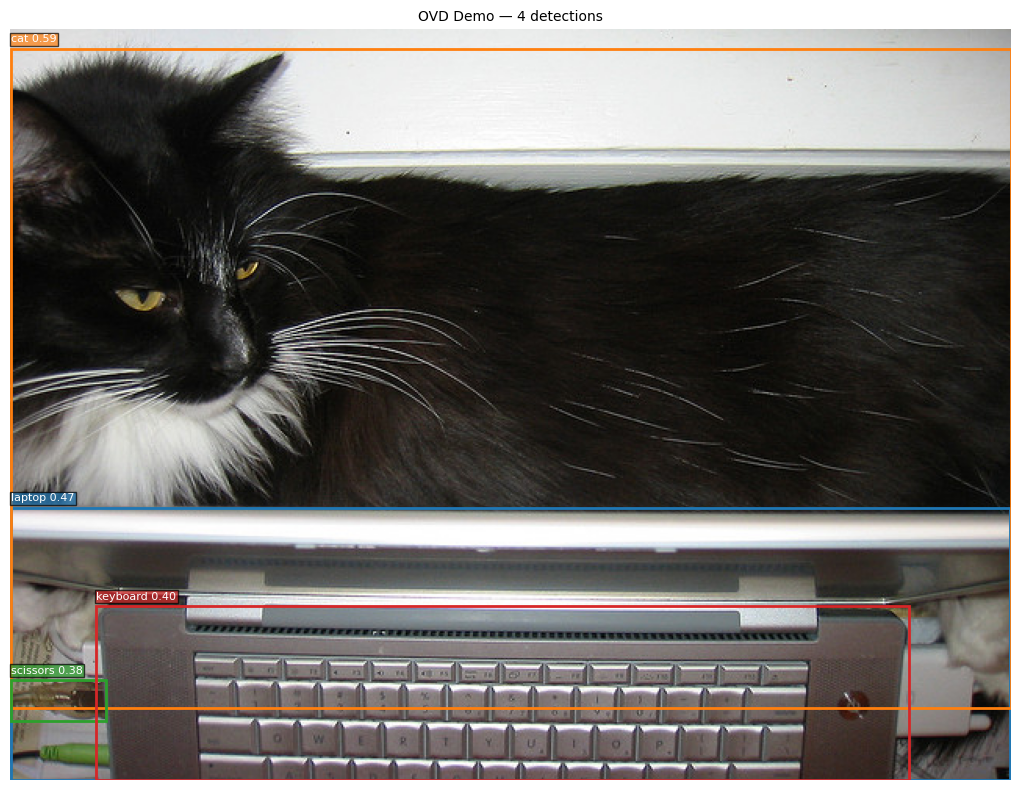

In [5]:
fig = draw_boxes(
    pil_img,
    result.boxes_xyxy,
    labels=result.phrases,
    scores=result.scores,
    title=f'OVD Demo — {len(result.boxes_xyxy)} detections',
    figsize=(12, 8),
)
plt.show()

## 3. 视觉定位（Visual Grounding Demo）

In [13]:
# 自由文本指代，无需预定义类别
expr = 'the cat on the left'

result_vg = model.predict(pil_img, expr)
print(f'表达式："{expr}"')
print(f'检测到 {len(result_vg.boxes_xyxy)} 个候选框')

if len(result_vg.boxes_xyxy) > 0:
    best_idx = int(np.argmax(result_vg.scores))
    print(f'最高分框（top-1）: score={result_vg.scores[best_idx]:.3f}  box={result_vg.boxes_xyxy[best_idx].astype(int)}')

表达式："the cat on the left"
检测到 1 个候选框
最高分框（top-1）: score=0.281  box=[  1   9 638 308]


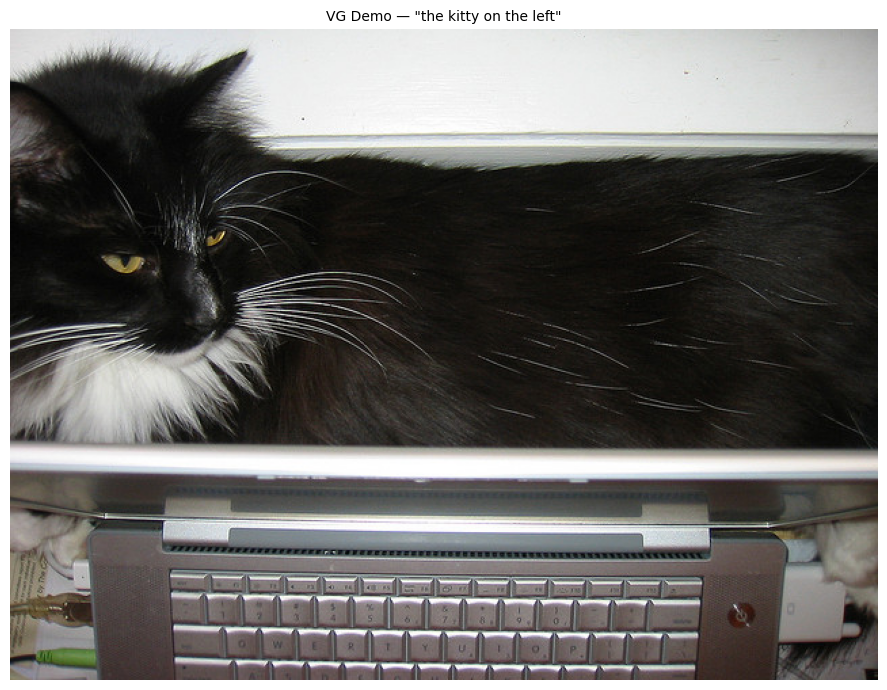

In [10]:
fig = draw_boxes(
    pil_img,
    result_vg.boxes_xyxy,
    labels=result_vg.phrases,
    scores=result_vg.scores,
    title=f'VG Demo — "{expr}"',
    figsize=(10, 7),
)
plt.show()

## 4. Prompt 模板对比（消融预览）

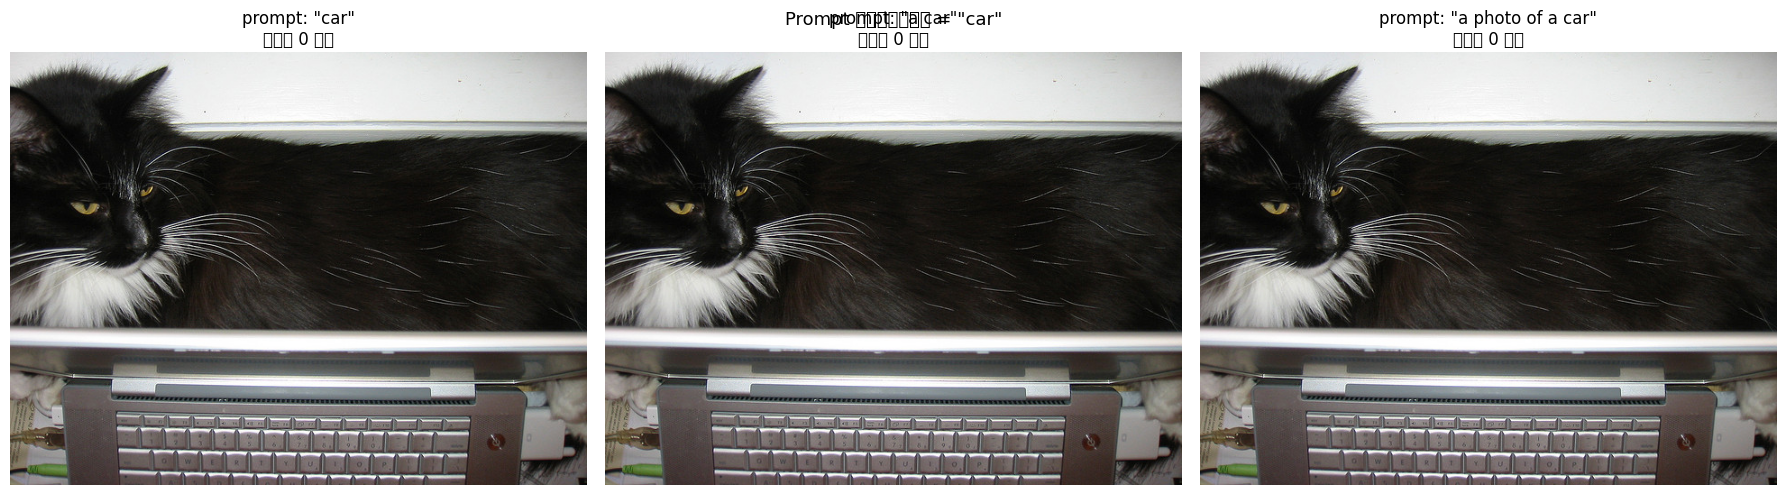

In [8]:
templates = ['{name}', 'a {name}', 'a photo of a {name}']
test_class = 'car'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, tmpl in zip(axes, templates):
    prompt_single = tmpl.format(name=test_class)
    res = model.predict(pil_img, prompt_single)
    ax.imshow(pil_img)
    ax.set_title(f'prompt: "{prompt_single}"\n检测到 {len(res.boxes_xyxy)} 个框')
    ax.axis('off')

    from matplotlib import patches
    for box in res.boxes_xyxy:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

plt.suptitle(f'Prompt 模板消融：类别 = "{test_class}"', fontsize=13)
plt.tight_layout()
plt.show()